<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/12_Missing_Everytype_DataHandling/4_Handling_missing_Numerical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Handling Missing Numerical Data

-> Numerical Data

1. Univariate row wise filling

2. Multivariate column wise filling

## a. Mean/Median Imputation

In [1]:
# it change the distribution
# comes extra ouliers
# covarience/corelation changes

In [2]:
# when to use
# 1. MCAR
# 2. 5% less

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
df1 = sns.load_dataset("titanic")
df2 = df1.iloc[:,[0,3,4,5,6]]

In [5]:
df2['family'] = df2['sibsp'] + df2['parch']

/tmp/ipykernel_3459/492083133.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['family'] = df2['sibsp'] + df2['parch']


In [6]:
df = df2.iloc[:,[0,1,4,5]]
df.head()

,survived,age,fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [7]:
df.isnull().mean()*100

,0
survived,0.00000
age,19.86532
fare,0.00000
family,0.00000


In [8]:
x = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

X_train.shape, X_test.shape

((712, 3), (179, 3))

In [9]:
X_train.isnull().mean()*100

,0
age,20.786517
fare,0.000000
family,0.000000


In [10]:
mean_age = X_train['age'].mean()
median_age = X_train['age'].median()

X_train['age_mean'] = X_train['age'].fillna(mean_age)
X_train['age_median'] = X_train['age'].fillna(median_age)


In [11]:
X_train.sample(5)

,age,fare,family,age_mean,age_median
866,27.0,13.8583,1,27.000000,27.00
847,35.0,7.8958,0,35.000000,35.00
229,NaN,25.4667,4,29.785904,28.75
249,54.0,26.0000,1,54.000000,54.00
215,31.0,113.2750,1,31.000000,31.00


In [12]:
print('Original age variable variance: ', X_train['age'].var())
print('Age variance after median imputation: ', X_train['age_median'].var())
print('Age variance after mean imputation: ', X_train['age_mean'].var())


Original age variable variance:  204.3495133904614
Age variance after median imputation:  161.9895663346054
Age variance after mean imputation:  161.81262452718673


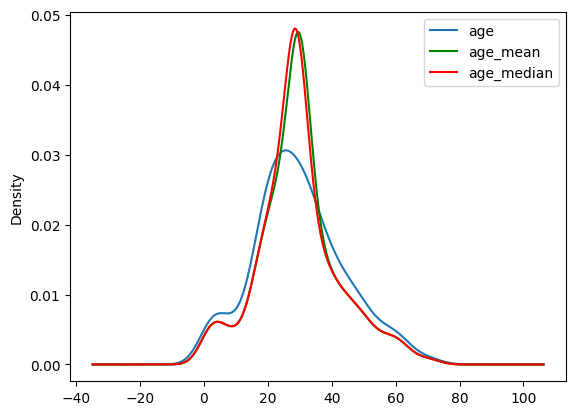

In [13]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# original
X_train['age'].plot(kind='kde', ax=ax)
X_train['age_mean'].plot(kind='kde', ax=ax, color='green')
X_train['age_median'].plot(kind='kde', ax=ax, color='red')

# add legends

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')


In [14]:
X_train.cov()  # covariance

,age,fare,family,age_mean,age_median
age,204.349513,71.512440,-6.498901,204.349513,204.349513
fare,71.512440,2368.246832,16.847264,56.626587,58.986531
family,-6.498901,16.847264,2.735252,-5.146106,-5.112563
age_mean,204.349513,56.626587,-5.146106,161.812625,161.812625
age_median,204.349513,58.986531,-5.112563,161.812625,161.989566


In [15]:
X_train.corr()

,age,fare,family,age_mean,age_median
age,1.000000,0.095814,-0.299113,1.000000,1.000000
fare,0.095814,1.000000,0.209323,0.091475,0.095235
family,-0.299113,0.209323,1.000000,-0.244610,-0.242883
age_mean,1.000000,0.091475,-0.244610,1.000000,0.999454
age_median,1.000000,0.095235,-0.242883,0.999454,1.000000


<Axes: >

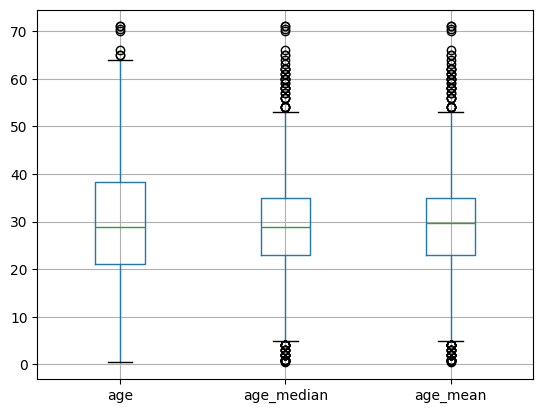

In [16]:
# boxplot

X_train[['age', 'age_median', 'age_mean']].boxplot()

# Using Sklearn

In [18]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [19]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [21]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['age'] )
], remainder='passthrough')

In [22]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['age'])])

In [23]:
trf.named_transformers_['imputer1'].statistics_


array([28.75])

In [24]:
X_train_tran = trf.transform(X_train)
X_test_tran = trf.transform(X_test)

X_train_tran

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])

# Arbitrary-value-imputation

it is apply when the data is not missing random

In [26]:
df.head()

,survived,age,fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [27]:
df.isnull().mean()* 100

,0
survived,0.00000
age,19.86532
fare,0.00000
family,0.00000


In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=2)

In [29]:
x_train['age_99'] = x_train['age'].fillna(99)
x_train['age_minus'] = x_train['age'].fillna(-1)



In [30]:
print('Original age variable variance: ', x_train['age'].var())
print('age variance after 99 wala imputation: ', x_train['age_99'].var())
print('age variance after -1 wala imputation: ', x_train['age_minus'].var())

Original age variable variance:  204.3495133904614
age variance after 99 wala imputation:  951.7275570187172
age variance after -1 wala imputation:  318.0896202624484


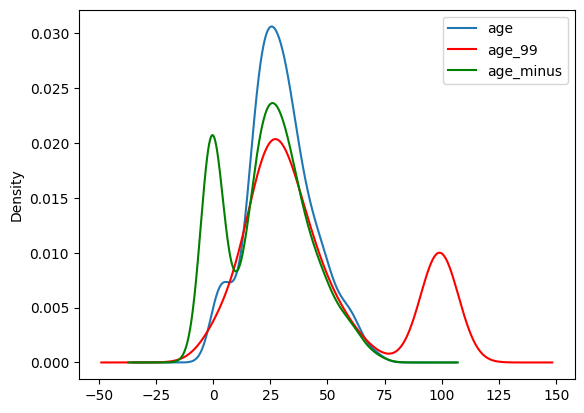

In [32]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1)

# original
x_train['age'].plot(kind='kde', ax=ax)


x_train['age_99'].plot(kind='kde', ax=ax, color='red')


x_train['age_minus'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [33]:
x_train.cov()

,age,fare,family,age_99,age_minus
age,204.349513,71.512440,-6.498901,204.349513,204.349513
fare,71.512440,2368.246832,16.847264,-101.053412,126.761454
family,-6.498901,16.847264,2.735252,-7.387287,-4.149246
age_99,204.349513,-101.053412,-7.387287,951.727557,-189.535540
age_minus,204.349513,126.761454,-4.149246,-189.535540,318.089620


In [34]:
x_train.corr()

,age,fare,family,age_99,age_minus
age,1.000000,0.095814,-0.299113,1.000000,1.000000
fare,0.095814,1.000000,0.209323,-0.067310,0.146049
family,-0.299113,0.209323,1.000000,-0.144787,-0.140668
age_99,1.000000,-0.067310,-0.144787,1.000000,-0.344476
age_minus,1.000000,0.146049,-0.140668,-0.344476,1.000000


# Using Sklearn

In [35]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [39]:
imputer1 = SimpleImputer(strategy='constant', fill_value=99)
imputer2 = SimpleImputer(strategy='constant', fill_value=999)

In [40]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['age'])
],
                        remainder= 'passthrough')

In [41]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['age'])])

In [42]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [44]:
X_train = trf.transform(X_train)

X_test = trf.transform(X_test)

In [45]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])

# 4. End of Distribution imputation

In [ ]:
# it is only apply when the data is not random missing data
# if the normally distributed data (mean + 3sigma) or (mean - 3sigma)

# skewed data (IQR proximity) -> ( Q1 - 1.5 IQR) or (Q3 + 1.5 IQR)